In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision.models as models
from torch.onnx import export

import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
# onnxファイルを作成する関数
def model_to_onnx(model, output_file, input_shape = (1, 3, 224, 224)):
  model.eval()
  input_tensor = torch.randn(input_shape).to('cpu')
  input_names = ['input']
  output_names = ['output']
  torch.onnx.export(model, input_tensor, output_file, verbose = False, input_names = input_names, output_names = output_names)
  return output_file

In [3]:
# モデル読み込み
model = models.resnet18(weights = "IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 10)  # CIFAR-10 にあわせて出力層変更
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(device)

cuda


In [4]:
# 訓練データセット作成
transform = transforms.Compose([transforms.Resize(224),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])   # 正規化したほうがいいらしい

trainset = torchvision.datasets.CIFAR10(root = "./data", train = True, download = True, transform = transform)
trainloader = DataLoader(trainset, batch_size = 400, shuffle = True)

In [5]:
# 訓練
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0001)
num_epochs = 7
epoch_loss_list = []

for epoch in range(num_epochs):
  model.train()
  total_loss = 0.0
  num_train = 0
  for inputs, labels in trainloader:
    inputs, labels = inputs.to(device), labels.to(device)   # データ代入

    # 重み更新のための手順
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    # 損失を記録
    total_loss += loss.item()*labels.size(0)
    num_train+=labels.size(0)

  epoch_loss_list.append(total_loss/num_train)
  print(f'Epoch[{epoch+1}/{num_epochs}], Loss: {epoch_loss_list[epoch]:.4f}')

Epoch[1/7], Loss: 0.4672
Epoch[2/7], Loss: 0.1145
Epoch[3/7], Loss: 0.0342
Epoch[4/7], Loss: 0.0094
Epoch[5/7], Loss: 0.0039
Epoch[6/7], Loss: 0.0023
Epoch[7/7], Loss: 0.0016


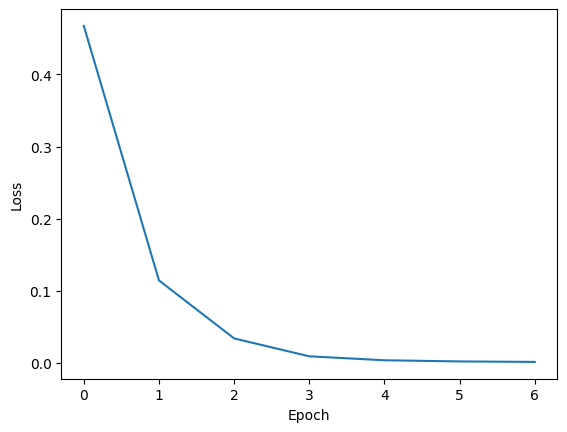

In [8]:
# 損失グラフ作成
plt.plot(epoch_loss_list)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [9]:
# onnxファイルとptファイルの作成
model = model.to('cpu')
model_to_onnx(model, "dense.onnx")
torch.save(model.state_dict(), "dense.pt")